## 1. Import Data

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Predictive Maintenance Dataset.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [55]:
failure_rate_by_type = df.groupby("Type")["Machine failure"].mean().reset_index()

failure_rate_by_type["Failure Rate (%)"] = failure_rate_by_type["Machine failure"] * 100

failure_rate_by_type

,Type,Machine failure,Failure Rate (%)
0,H,0.020937,2.093719
1,L,0.039167,3.916667
2,M,0.027694,2.769436


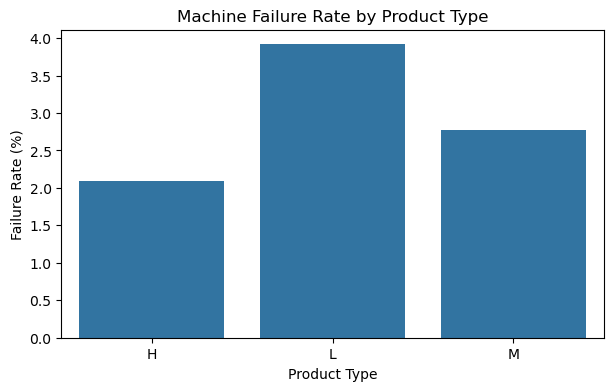

In [56]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=failure_rate_by_type,
    x="Type",
    y="Failure Rate (%)"
)

plt.title("Machine Failure Rate by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Failure Rate (%)")

plt.show()

Although product type L has the highest absolute number of failures, failure rate is a better metric because each product type has a different sample size. This analysis compares the percentage of failed records within each product type.

## 2. Engineered Features

Feature engineering is used to create new variables that better represent machine operating conditions. Based on the initial EDA, temperature behavior, machine load, and accumulated tool wear appear to be important factors related to machine failure. Therefore, this section creates new features to capture thermal load, mechanical power demand, and tool wear risk level.

Feature 1: Temperature Difference

`Temperature difference [K]` measures the gap between process temperature and air temperature. This feature may better represent machine thermal load than using both temperature variables separately.

In [57]:
df["Temperature difference [K]"] = (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)

Feature 2: Power Proxy

`Power proxy [W]` estimates mechanical power demand using torque and rotational speed. It is calculated from the relationship between torque and angular velocity.

In [58]:
import numpy as np

df["Power proxy [W]"] = (
    df["Torque [Nm]"] * df["Rotational speed [rpm]"] * 2 * np.pi / 60
)

Feature 3: Tool Wear Level

`Tool wear level` converts accumulated tool wear time into categorical risk levels. This makes the feature easier to interpret from a maintenance perspective.

In [59]:
df["Tool wear level"] = pd.cut(
    df["Tool wear [min]"],
    bins=[-1, 80, 160, 260],
    labels=["Low", "Medium", "High"])


In [60]:
wear_failure_rate = df.groupby("Tool wear level", observed=True)["Machine failure"].mean().reset_index()
wear_failure_rate["Failure Rate (%)"] = wear_failure_rate["Machine failure"] * 100

wear_failure_rate

,Tool wear level,Machine failure,Failure Rate (%)
0,Low,0.022045,2.204515
1,Medium,0.021936,2.193584
2,High,0.068006,6.800618


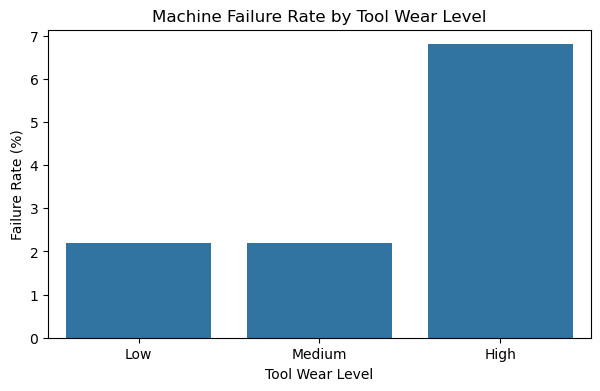

In [61]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=wear_failure_rate,
    x="Tool wear level",
    y="Failure Rate (%)"
)

plt.title("Machine Failure Rate by Tool Wear Level")
plt.xlabel("Tool Wear Level")
plt.ylabel("Failure Rate (%)")

plt.show()

In [62]:
df[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Temperature difference [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Power proxy [W]",
        "Tool wear [min]",
        "Tool wear level",
        "Machine failure"
    ]
].head()

,Air temperature [K],Process temperature [K],Temperature difference [K],Rotational speed [rpm],Torque [Nm],Power proxy [W],Tool wear [min],Tool wear level,Machine failure
0,298.1,308.6,10.5,1551,42.8,6951.590560,0,Low,0
1,298.2,308.7,10.5,1408,46.3,6826.722724,3,Low,0
2,298.1,308.5,10.4,1498,49.4,7749.387543,5,Low,0
3,298.2,308.6,10.4,1433,39.5,5927.504659,7,Low,0
4,298.2,308.7,10.5,1408,40.0,5897.816608,9,Low,0


In [63]:
df[
    [
        "Temperature difference [K]",
        "Power proxy [W]",
        "Tool wear [min]"
    ]
].describe()

,Temperature difference [K],Power proxy [W],Tool wear [min]
count,10000.000000,10000.000000,10000.000000
mean,10.000630,6279.744953,107.951000
std,1.001094,1067.418295,63.654147
min,7.600000,1148.440610,0.000000
25%,9.300000,5561.184484,53.000000
50%,9.800000,6271.027344,108.000000
75%,11.000000,7003.002724,162.000000
max,12.100000,10469.923005,253.000000


## 3. Modeling Dataset Preparation

### Create a copy for modeling

In [64]:
model_df = df.copy()

### Drop columns that should not be used as model inputs

In [65]:
model_df = model_df.drop(
    columns=[
        "UDI",
        "Product ID",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
)

### Convert categorical variables into numeric dummy variables

In [66]:
model_df = pd.get_dummies(
    model_df,
    columns=["Type", "Tool wear level"],
    drop_first=True
)

### Define input features X and target variable y

In [67]:
X = model_df.drop(columns=["Machine failure"])
y = model_df["Machine failure"]

### Check results

In [68]:
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.value_counts())
display(y.value_counts(normalize=True) * 100)

X shape: (10000, 11)
y shape: (10000,)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature difference [K],Power proxy [W],Type_L,Type_M,Tool wear level_Medium,Tool wear level_High
0,298.1,308.6,1551,42.8,0,10.5,6951.590560,False,True,False,False
1,298.2,308.7,1408,46.3,3,10.5,6826.722724,True,False,False,False
2,298.1,308.5,1498,49.4,5,10.4,7749.387543,True,False,False,False
3,298.2,308.6,1433,39.5,7,10.4,5927.504659,True,False,False,False
4,298.2,308.7,1408,40.0,9,10.5,5897.816608,True,False,False,False


Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

## Modeling Dataset Check

After feature engineering and one-hot encoding, the modeling dataset contains 10,000 records and 11 input features. The target variable `Machine failure` contains 10,000 labels, matching the number of input records.

The categorical variables `Type` and `Tool wear level` were successfully converted into dummy variables. The model input dataset no longer contains raw text categories, making it suitable for machine learning models.

The target distribution shows a strong class imbalance. There are 9,661 normal operation records and 339 machine failure records. This means only 3.39% of the dataset represents failure cases. Because of this imbalance, accuracy alone will not be a sufficient evaluation metric. Future model evaluation should focus on precision, recall, F1-score, confusion matrix, and ROC-AUC.